## 1) Setup, Styling & Palette


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from pathlib import Path
import seaborn as sns

NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parent
IMAGES_DIR = REPO_ROOT / "reports" / "figures"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name, dpi=240):
    path = IMAGES_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.fontsize": 10,
    "savefig.dpi": 240,
})

def pct_fmt(x, pos=None): return f"{x:.0%}"

PALETTE = ["#4472C4","#ED7D31","#A5A5A5","#70AD47","#FFC000","#5B9BD5","#C00000","#7030A0"]
def color_cycle(i): return PALETTE[i % len(PALETTE)]
CMAP_SCATTER = "plasma"
CMAP_HEATMAP = "viridis"

def fmt_usd(x, pos=None):
    try: return f"${x:,.0f}"
    except Exception: return str(x)

def fmt_pct(x, pos=None): return f"{x*100:.0f}%"

def annotate_bars(ax, fmt="{:,.0f}", offset=4, color="#333333"):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.annotate(fmt.format(h),
                        (p.get_x()+p.get_width()/2, h),
                        ha='center', va='bottom', fontsize=9.5, color=color,
                        xytext=(0, offset), textcoords="offset points")

def add_vline_callout(ax, x, text, ls="--", lw=1.8, color="#333333", text_color=None):
    ax.axvline(x, linestyle=ls, linewidth=lw, color=color)
    text_color = text_color or color
    ylim = ax.get_ylim()
    ax.text(x, ylim[1]*0.95, text, ha="left", va="top", fontsize=10.5, color=text_color)

def trend_line(ax, x, y, color="#333333", ls="--", lw=2):
    z = np.polyfit(x, y, 1); p = np.poly1d(z)
    xs = np.linspace(np.min(x), np.max(x), 200)
    ax.plot(xs, p(xs), ls, lw=lw, color=color)
    return z

DATA_PATH = r"/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
display(df.describe(include='all').T)

Shape: (11933, 21)


,id,age,gender,race,education,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,...,a1c,glucose,smoking_current,smoking_ever,physical_activity_freq,sleep_hours,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type
0,130378.0,43.0,Male,Non-Hispanic Asian,College graduate or above,5.00,86.9,179.5,27.0,135.0,...,5.6,113.0,Yes,NaN,45.0,9.5,No,Insured,Yes,Private only
1,130379.0,66.0,Male,Non-Hispanic White,College graduate or above,5.00,101.8,174.2,33.5,121.0,...,5.6,99.0,Yes,NaN,45.0,9.0,No,Insured,NaN,Both
2,130380.0,44.0,Female,Other Hispanic,High school/GED,1.41,69.4,152.9,29.7,111.0,...,6.2,156.0,No,NaN,NaN,8.0,Yes,Insured,NaN,Public only
3,130381.0,5.0,Female,Other Race / Multi,NaN,1.53,34.3,120.1,23.8,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,No,Insured,Yes,Public only
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,13.6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,No,Insured,NaN,Private only


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,11933.0,NaN,NaN,NaN,136344.0,3444.904716,130378.0,133361.0,136344.0,139327.0,142310.0
age,11933.0,NaN,NaN,NaN,38.317858,25.60199,0.0,13.0,37.0,62.0,80.0
gender,11933,2,Female,6358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,11933,6,Non-Hispanic White,6217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,7783,5,College graduate or above,2625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_poverty_ratio,9892.0,NaN,NaN,NaN,2.708174,1.670119,0.0,1.18,2.5,4.5,5.0
weight_kg,8754.0,NaN,NaN,NaN,70.549037,30.389021,2.7,54.2,71.7,89.1,248.2
height_cm,8499.0,NaN,NaN,NaN,159.664549,19.864943,79.1,154.4,163.6,172.1,200.7
bmi,8471.0,NaN,NaN,NaN,27.246665,8.137781,11.1,21.6,26.4,31.7,74.8
sbp,7517.0,NaN,NaN,NaN,119.288546,18.561052,61.0,106.0,117.0,130.0,232.0


## 2) Missingness

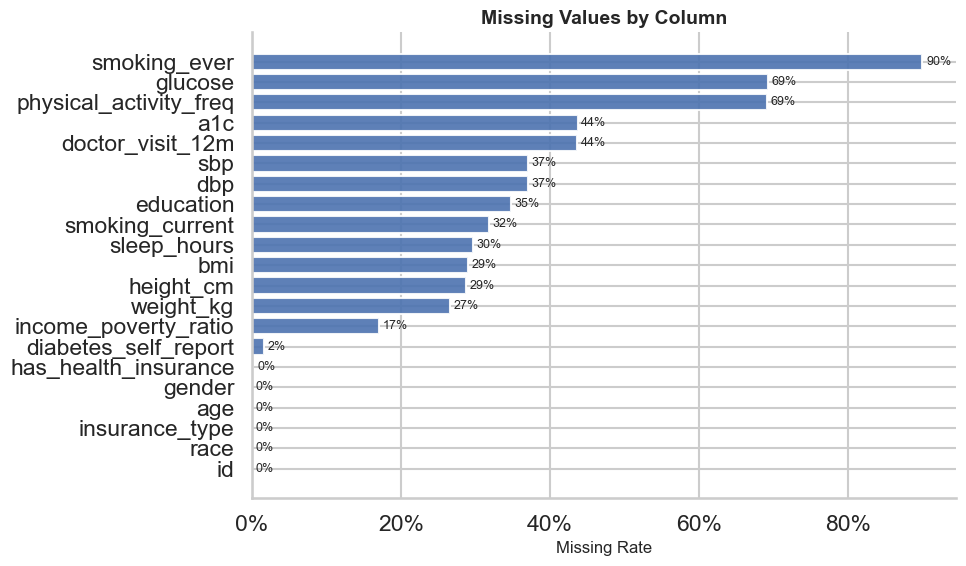

In [11]:
from matplotlib.ticker import FuncFormatter

missing = df.isna().mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing.index, missing.values, alpha=0.9)
ax.set_title("Missing Values by Column")
ax.set_xlabel("Missing Rate")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))

for y, v in enumerate(missing.values):
    ax.text(v + 0.005, y, f"{v:.0%}", va="center", fontsize=9)

fig.tight_layout() 
plt.show()
savefig(fig, "missing_values.png")  

## 3) Numeric Distributions

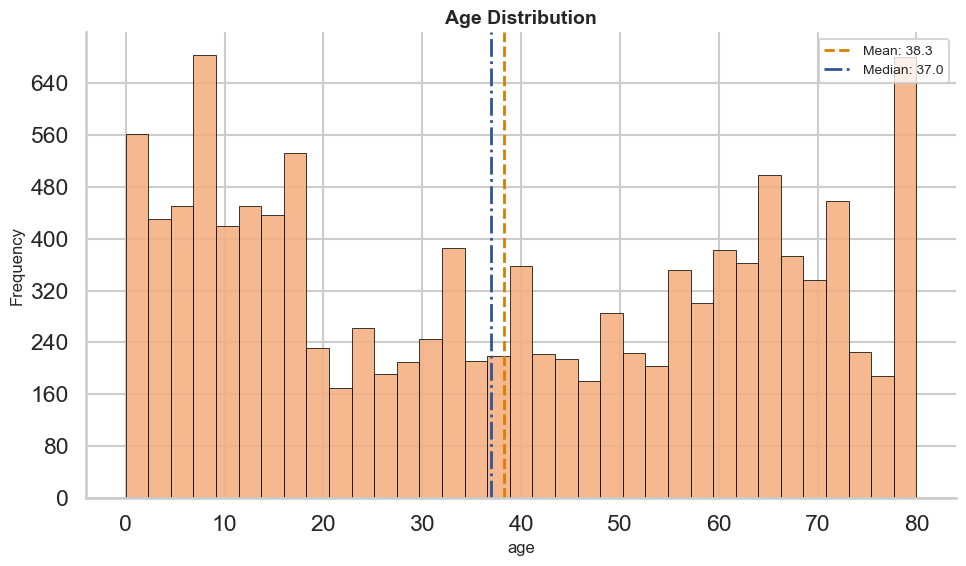

💡 KEY INSIGHTS: age Distribution
✓ Mean: 38.32 | Median: 37.00 | Std: 25.60
✓ Skewness: 0.09 (approximately symmetric)
✓ Age quartiles: Q1=13.0, Q2=37.0, Q3=62.0


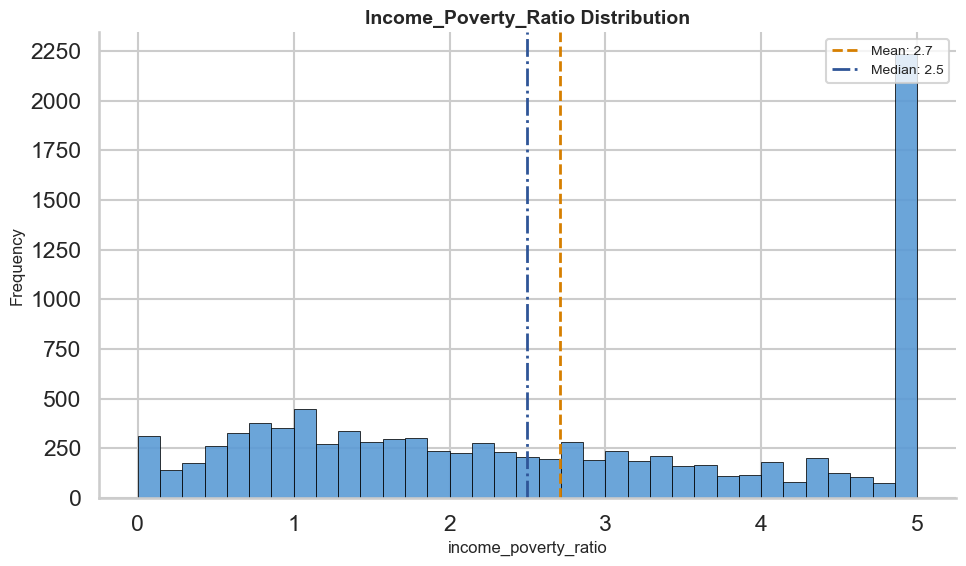

💡 KEY INSIGHTS: income_poverty_ratio Distribution
✓ Mean: 2.71 | Median: 2.50 | Std: 1.67
✓ Skewness: 0.12 (approximately symmetric)


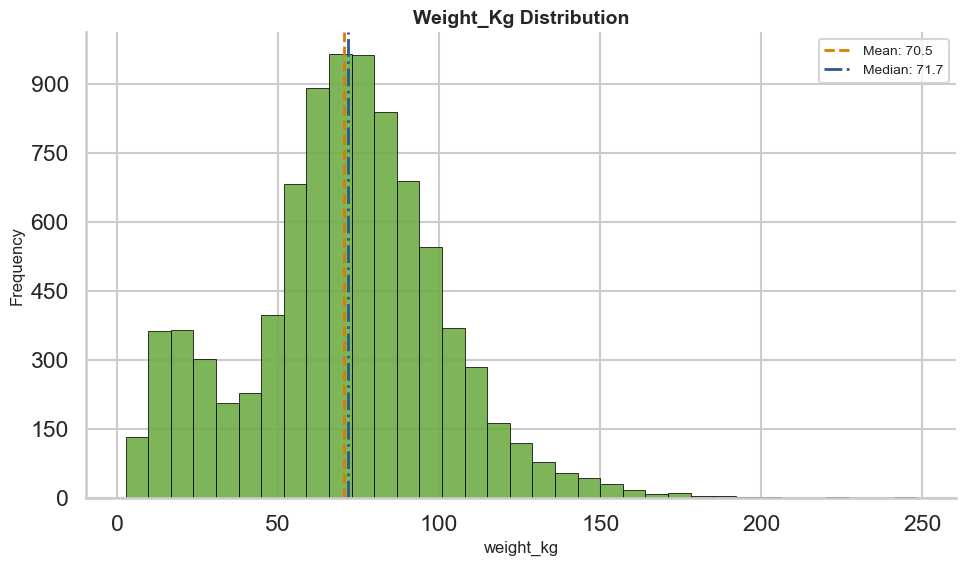

💡 KEY INSIGHTS: weight_kg Distribution
✓ Mean: 70.55 | Median: 71.70 | Std: 30.39
✓ Skewness: 0.11 (approximately symmetric)


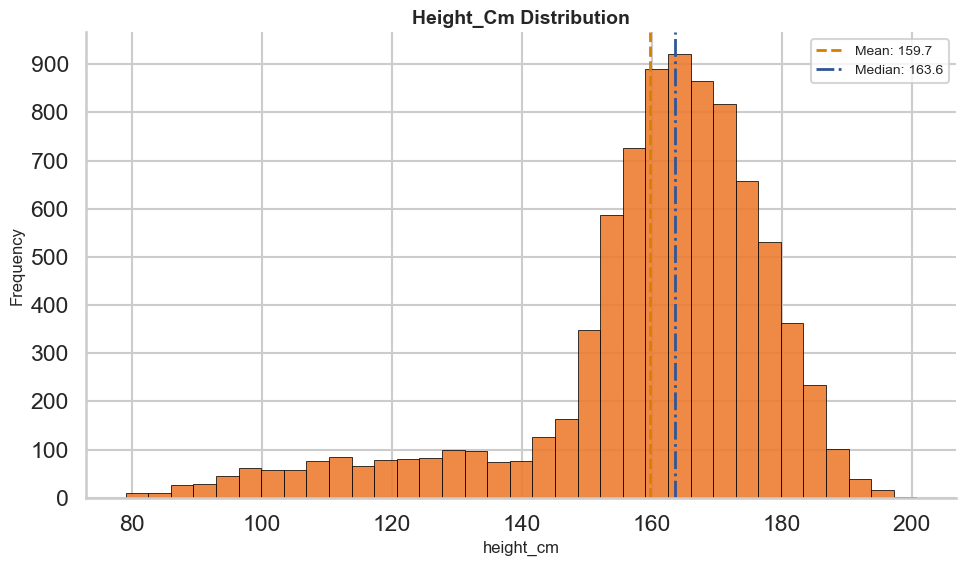

💡 KEY INSIGHTS: height_cm Distribution
✓ Mean: 159.66 | Median: 163.60 | Std: 19.86
✓ Skewness: -1.51 (left-skewed)


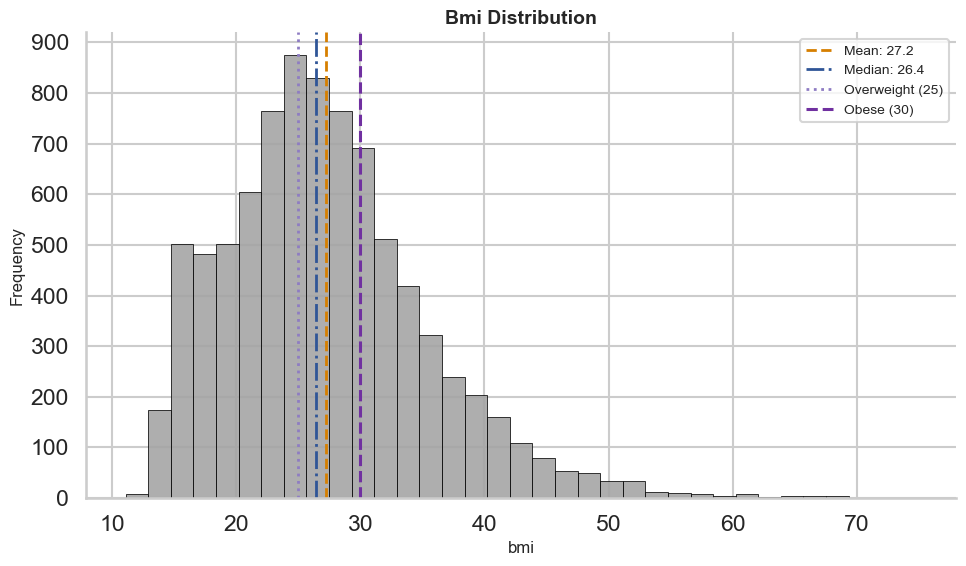

💡 KEY INSIGHTS: bmi Distribution
✓ Mean: 27.25 | Median: 26.40 | Std: 8.14
✓ Skewness: 0.91 (right-skewed)
✓ Obese (BMI≥30): 31.9% | Underweight (BMI<18.5): 14.1%


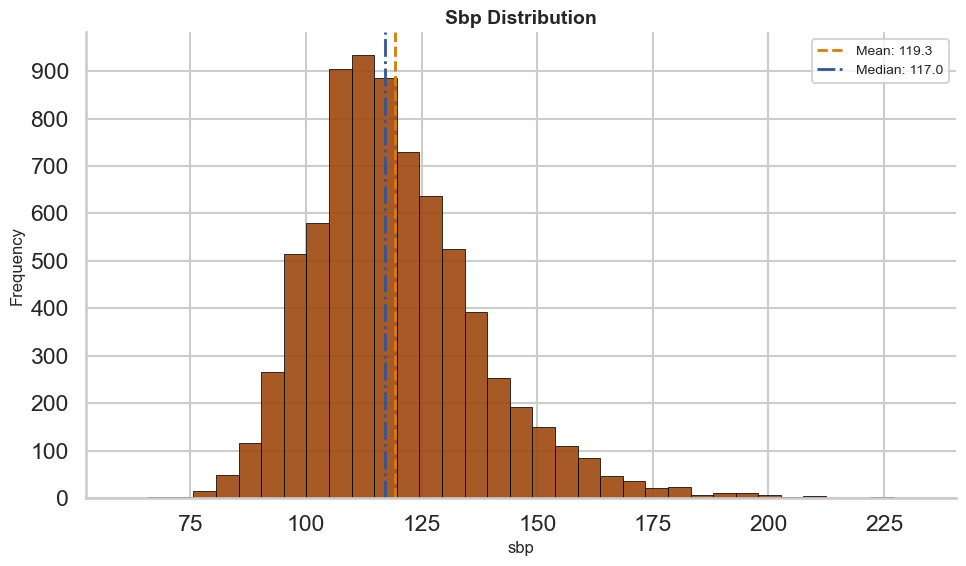

💡 KEY INSIGHTS: sbp Distribution
✓ Mean: 119.29 | Median: 117.00 | Std: 18.56
✓ Skewness: 0.97 (right-skewed)


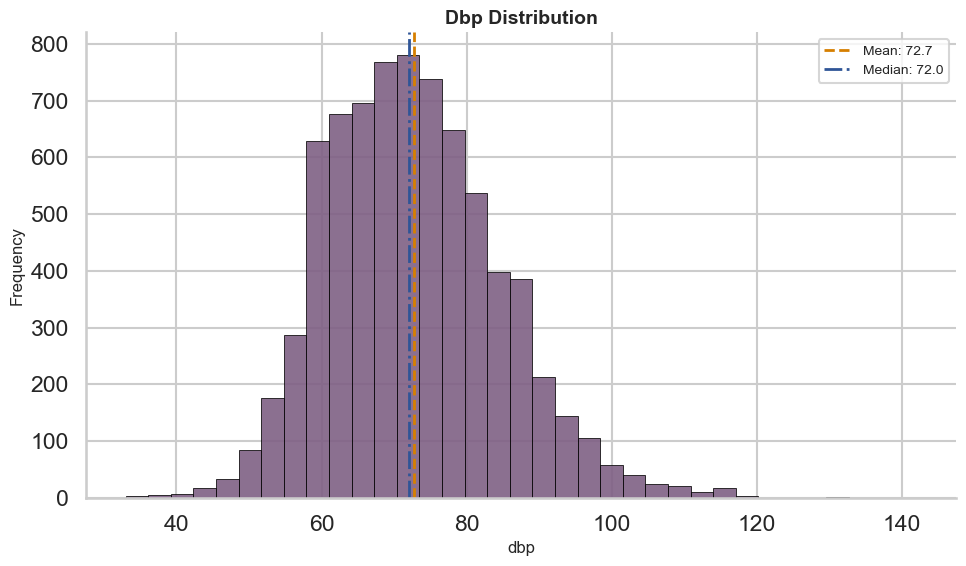

💡 KEY INSIGHTS: dbp Distribution
✓ Mean: 72.75 | Median: 72.00 | Std: 11.90
✓ Skewness: 0.51 (right-skewed)


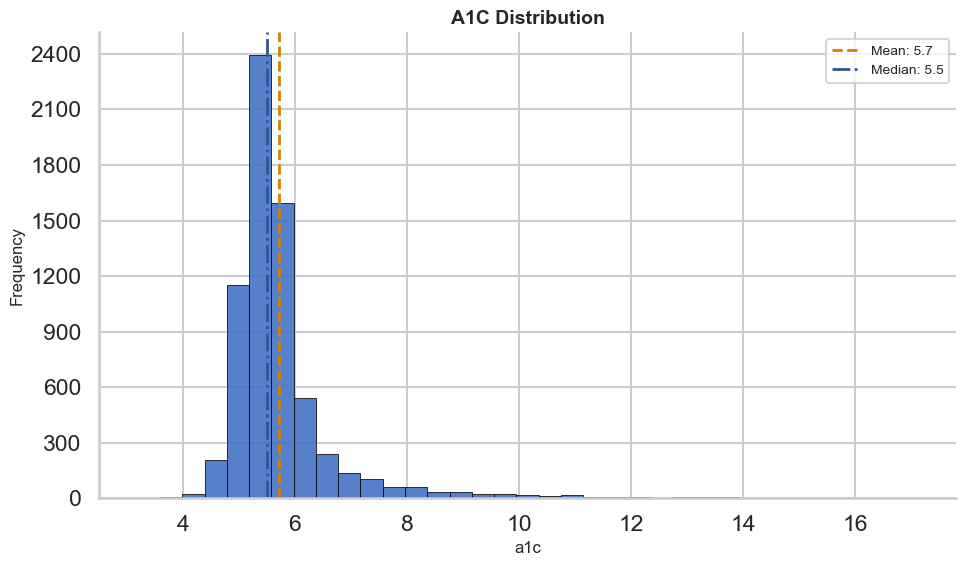

💡 KEY INSIGHTS: a1c Distribution
✓ Mean: 5.71 | Median: 5.50 | Std: 1.05
✓ Skewness: 3.89 (right-skewed)


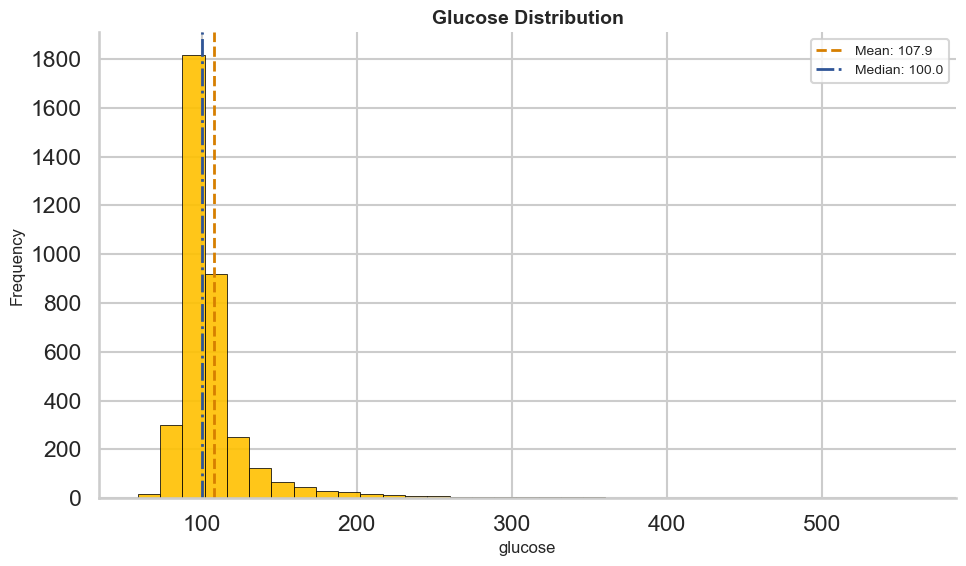

💡 KEY INSIGHTS: glucose Distribution
✓ Mean: 107.88 | Median: 100.00 | Std: 32.48
✓ Skewness: 4.73 (right-skewed)


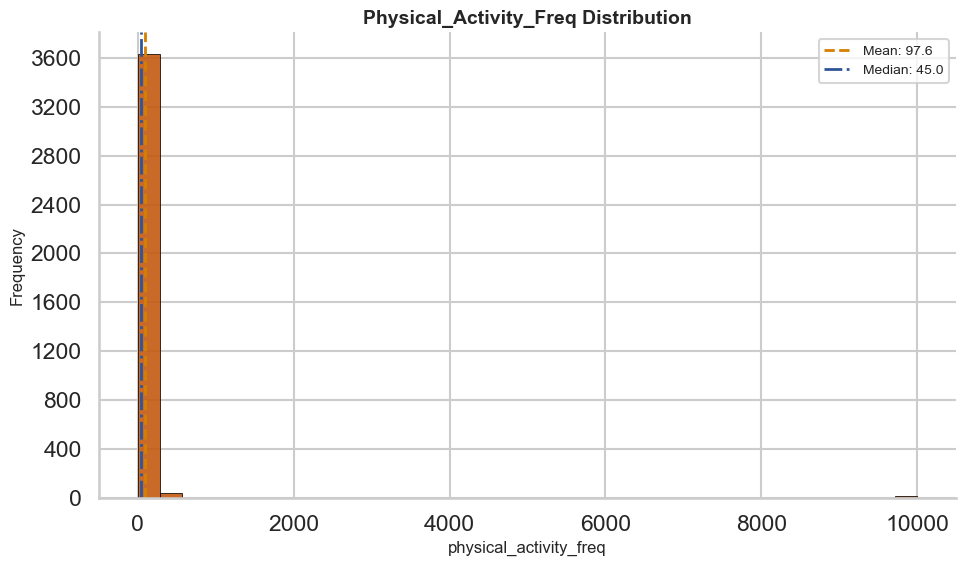

💡 KEY INSIGHTS: physical_activity_freq Distribution
✓ Mean: 97.57 | Median: 45.00 | Std: 605.42
✓ Skewness: 15.99 (right-skewed)


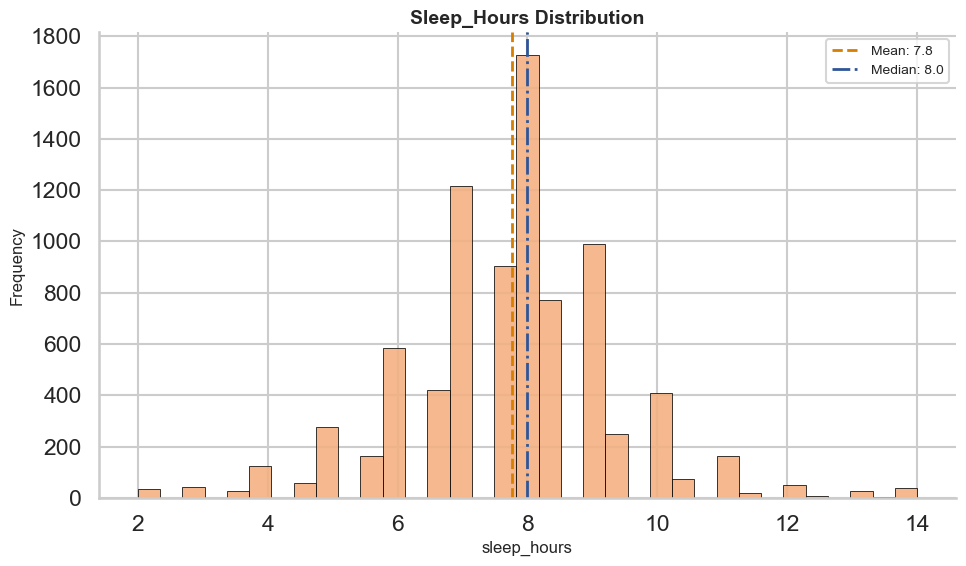

💡 KEY INSIGHTS: sleep_hours Distribution
✓ Mean: 7.76 | Median: 8.00 | Std: 1.62
✓ Skewness: 0.01 (approximately symmetric)


In [3]:
import numpy as np
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import MaxNLocator

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 12, "legend.fontsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "savefig.dpi": 240
})

PALETTE = ["#F4B183","#5B9BD5","#70AD47","#ED7D31","#A5A5A5",
           "#9E480E","#7F6084","#4472C4","#FFC000","#C55A11"]

def _bar_color(i):  
    return PALETTE[i % len(PALETTE)]

numeric_cols = [
    'age','income_poverty_ratio','weight_kg','height_cm','bmi',
    'sbp','dbp','a1c','glucose','physical_activity_freq','sleep_hours'
]

for i, col in enumerate(numeric_cols):
    if col not in df.columns:
        continue
    s = df[col].dropna()
    if s.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(
        s, bins=35, color=_bar_color(i), alpha=0.9,
        edgecolor="black", linewidth=0.6
    )

    ax.set_title(f"{col.title()} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    mean_v, med_v = s.mean(), s.median()
    ax.axvline(mean_v, ls="--", lw=2, color="#D67F00", label=f"Mean: {mean_v:.1f}")
    ax.axvline(med_v, ls="-.", lw=2, color="#2F5597", label=f"Median: {med_v:.1f}")

    if col == "bmi":
        ax.axvline(25, ls=":",  lw=2, color="#8E7CC3", label="Overweight (25)")
        ax.axvline(30, ls="--", lw=2.2, color="#7030A0", label="Obese (30)")

    ax.legend(loc="upper right", frameon=True)

    fig.tight_layout()

    out_path = IMAGES_DIR / f"dist_{col}.png"
    fig.savefig(out_path, dpi=240, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"💡 KEY INSIGHTS: {col} Distribution")
    print("="*60)
    print(f"✓ Mean: {mean_v:.2f} | Median: {med_v:.2f} | Std: {s.std():.2f}")
    try:
        sk = s.skew()
        shape = 'right-skewed' if sk > 0.3 else ('left-skewed' if sk < -0.3 else 'approximately symmetric')
        print(f"✓ Skewness: {sk:.2f} ({shape})")
    except Exception:
        pass
    if col == 'bmi':
        print(f"✓ Obese (BMI≥30): {(s>=30).mean()*100:.1f}% | Underweight (BMI<18.5): {(s<18.5).mean()*100:.1f}%")
    elif col == 'age':
        print(f"✓ Age quartiles: Q1={s.quantile(0.25):.1f}, Q2={s.quantile(0.50):.1f}, Q3={s.quantile(0.75):.1f}")
    print("="*60)


## 4) Categorical Distributions

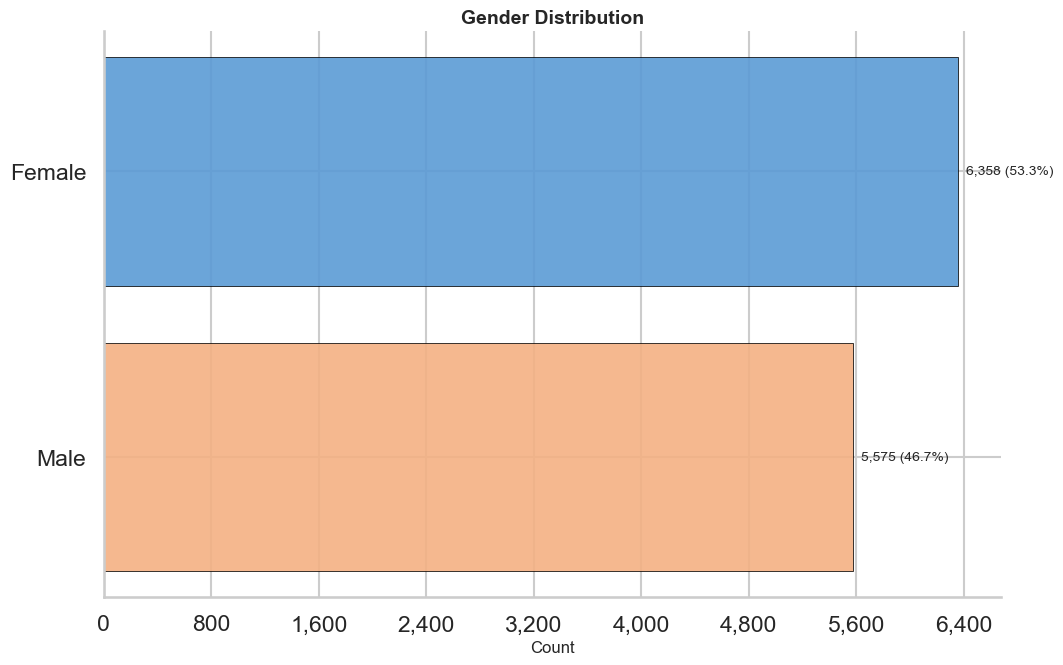

💡 KEY INSIGHTS: gender
✓ Female: 6,358 (53.3%)
✓ Male: 5,575 (46.7%)


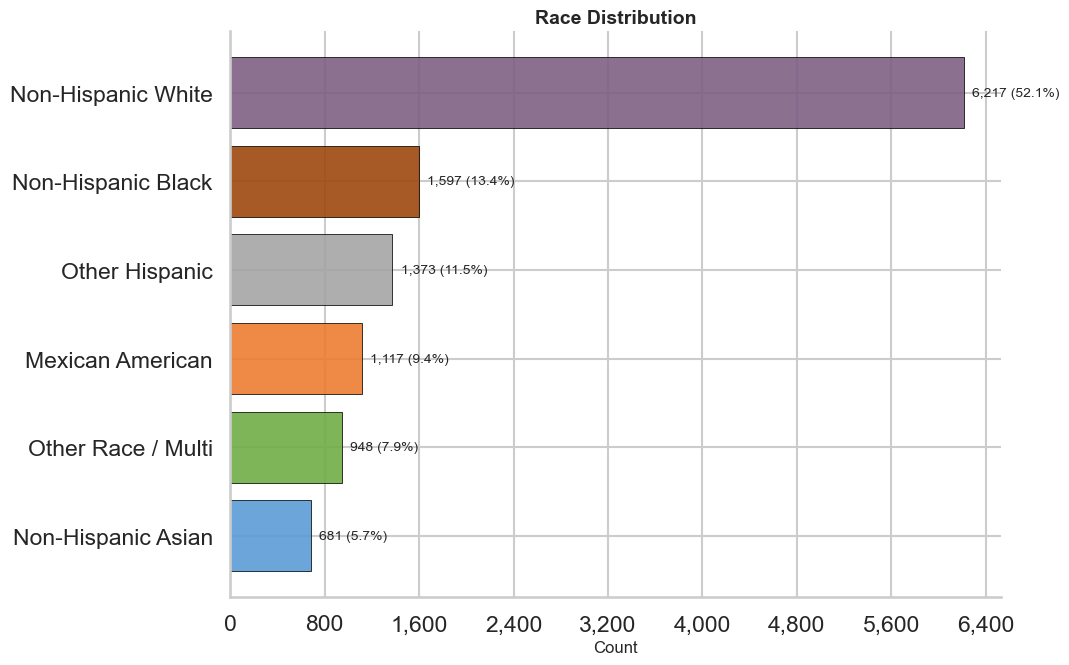

💡 KEY INSIGHTS: race
✓ Non-Hispanic White: 6,217 (52.1%)
✓ Non-Hispanic Black: 1,597 (13.4%)
✓ Other Hispanic: 1,373 (11.5%)
✓ Mexican American: 1,117 (9.4%)
✓ Other Race / Multi: 948 (7.9%)
✓ Others grouped below top-5


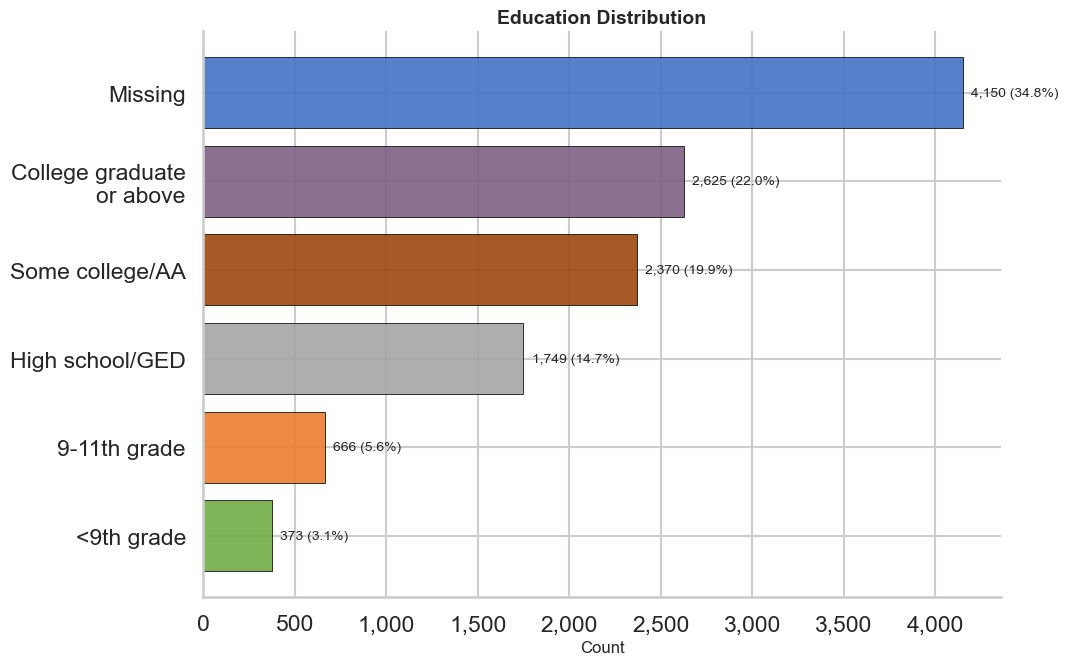

💡 KEY INSIGHTS: education
✓ Missing: 4,150 (34.8%)
✓ College graduate or above: 2,625 (22.0%)
✓ Some college/AA: 2,370 (19.9%)
✓ High school/GED: 1,749 (14.7%)
✓ 9-11th grade: 666 (5.6%)
✓ Others grouped below top-5


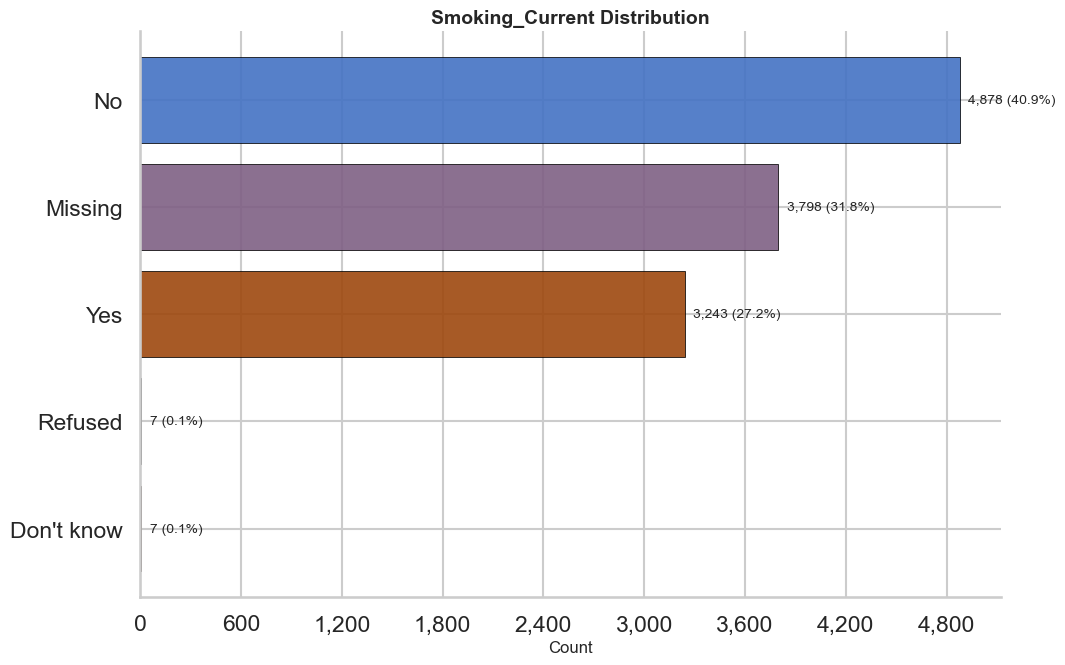

💡 KEY INSIGHTS: smoking_current
✓ No: 4,878 (40.9%)
✓ Missing: 3,798 (31.8%)
✓ Yes: 3,243 (27.2%)
✓ Don't know: 7 (0.1%)
✓ Refused: 7 (0.1%)


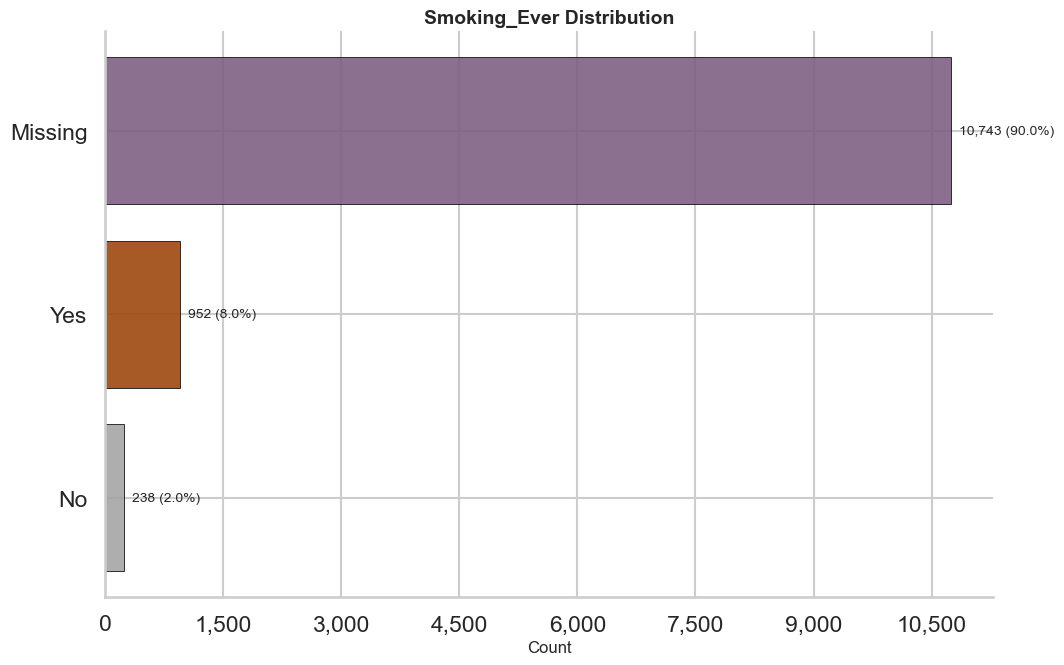

💡 KEY INSIGHTS: smoking_ever
✓ Missing: 10,743 (90.0%)
✓ Yes: 952 (8.0%)
✓ No: 238 (2.0%)


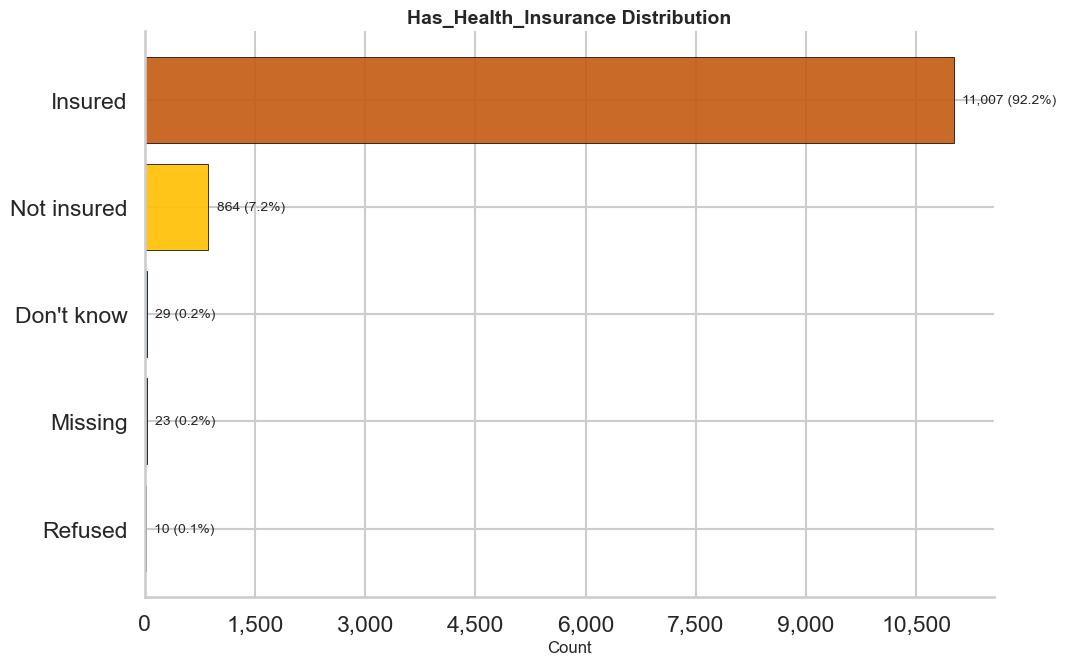

💡 KEY INSIGHTS: has_health_insurance
✓ Insured: 11,007 (92.2%)
✓ Not insured: 864 (7.2%)
✓ Don't know: 29 (0.2%)
✓ Missing: 23 (0.2%)
✓ Refused: 10 (0.1%)


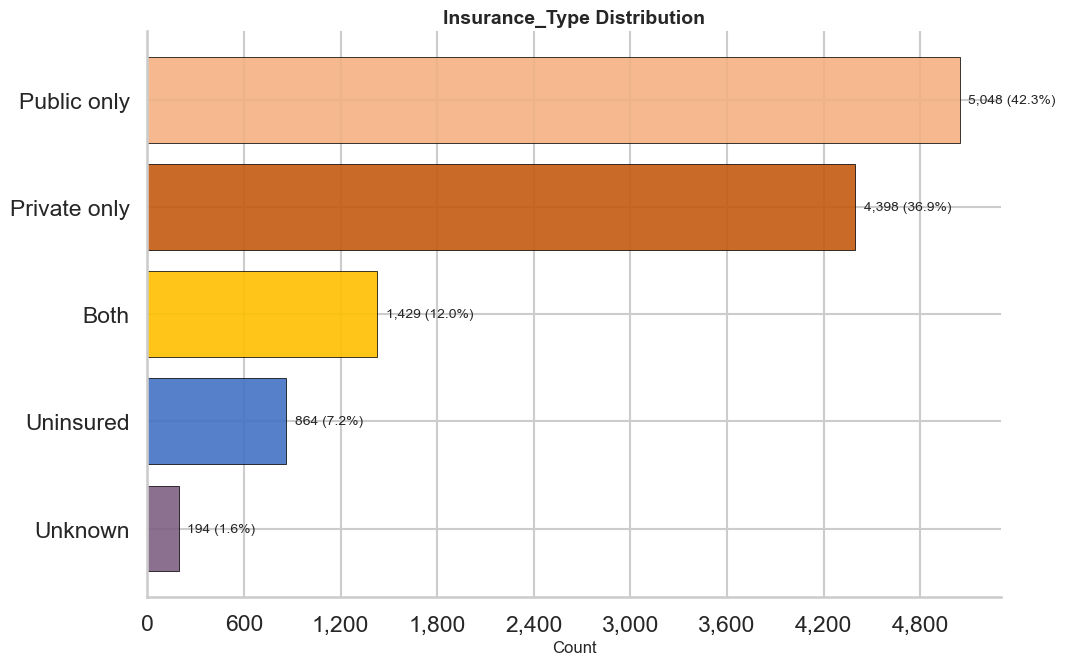

💡 KEY INSIGHTS: insurance_type
✓ Public only: 5,048 (42.3%)
✓ Private only: 4,398 (36.9%)
✓ Both: 1,429 (12.0%)
✓ Uninsured: 864 (7.2%)
✓ Unknown: 194 (1.6%)


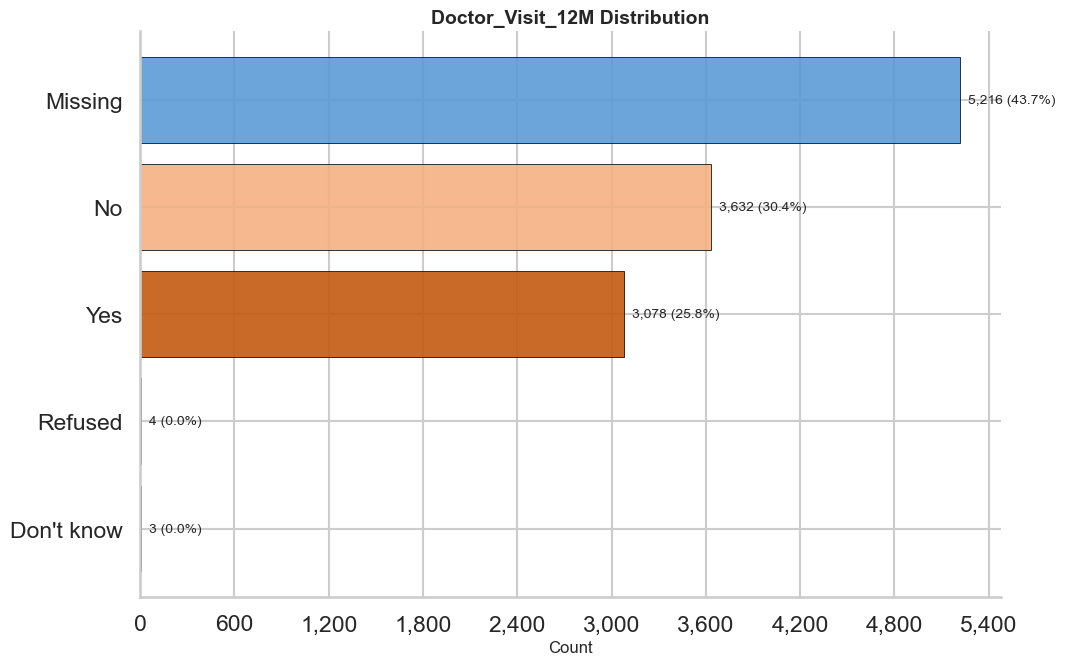

💡 KEY INSIGHTS: doctor_visit_12m
✓ Missing: 5,216 (43.7%)
✓ No: 3,632 (30.4%)
✓ Yes: 3,078 (25.8%)
✓ Refused: 4 (0.0%)
✓ Don't know: 3 (0.0%)


In [4]:
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator, FuncFormatter

def _wrap_label(x, width=18):
    s = str(x)
    if len(s) <= width: 
        return s

    parts, line, out = s.split(), "", []
    for w in parts:
        if len(line) + 1 + len(w) <= width:
            line = (line + " " + w).strip()
        else:
            out.append(line); line = w
    if line: out.append(line)
    return "\n".join(out)

categorical_cols = [
    'gender','race','education','smoking_current','smoking_ever',
    'has_health_insurance','insurance_type','doctor_visit_12m'
]

for i, col in enumerate(categorical_cols):
    if col not in df.columns:
        continue

    counts = (
        df[col]
        .fillna("Missing")
        .astype("string")
        .value_counts(dropna=False)
    )
    total = counts.sum()
    counts = counts.sort_values(ascending=True)
    colors = [PALETTE[(i + j) % len(PALETTE)] for j in range(len(counts))]

    fig, ax = plt.subplots(figsize=(11, 7))
    y = np.arange(len(counts))
    ax.barh(y, counts.values, color=colors, alpha=0.9, edgecolor="black", linewidth=0.6)

    ax.set_title(f"{col.title()} Distribution")
    ax.set_xlabel("Count"); ax.set_ylabel("")
    ax.set_yticks(y)
    ax.set_yticklabels([_wrap_label(k) for k in counts.index])

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(v):,}"))

    for yy, v in zip(y, counts.values):
        ax.annotate(f"{v:,} ({v/total:.1%})",
                    xy=(v, yy), xytext=(6, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=10)

    fig.tight_layout()

    out_path = IMAGES_DIR / f"count_{col}.png"
    fig.savefig(out_path, dpi=240, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"💡 KEY INSIGHTS: {col}")
    print("="*60)
    for k, v in counts.sort_values(ascending=False).head(5).items():
        print(f"✓ {k}: {v:,} ({v/total:.1%})")
    if len(counts) > 5:
        print("✓ Others grouped below top-5")
    print("="*60)


## 5) Demographics: Education & Race × Insurance

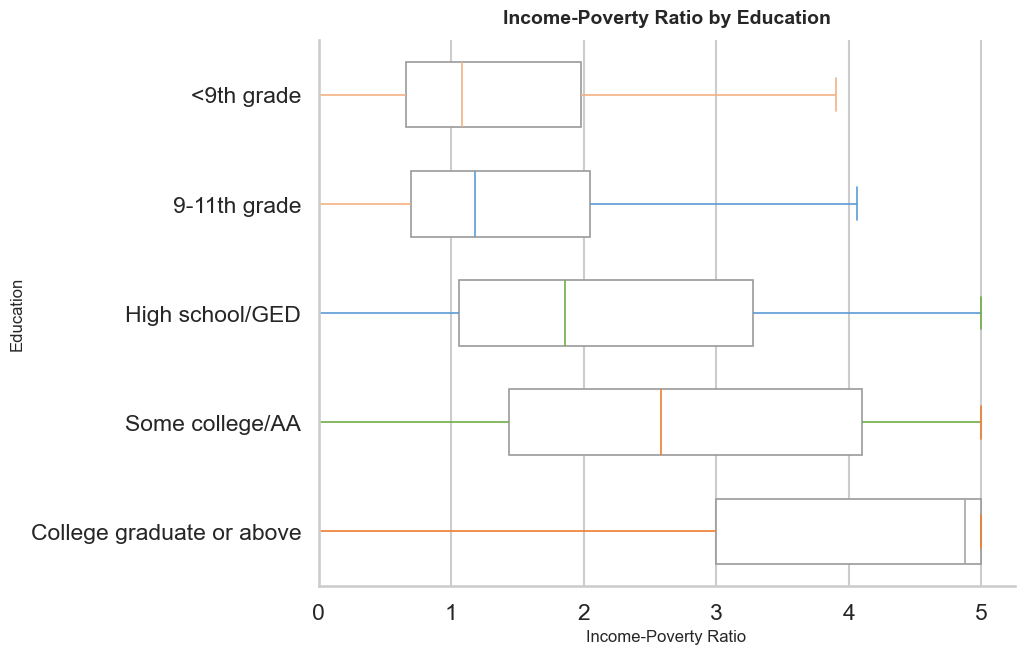

💡 KEY INSIGHTS: Education vs Income
✓ Median IPR — College graduate or above: 4.88
✓ Median IPR — Some college/AA: 2.58
✓ Median IPR — High school/GED: 1.86
✓ Median IPR — 9-11th grade: 1.18
✓ Median IPR — <9th grade: 1.08
✓ Gap (max - min): 3.79


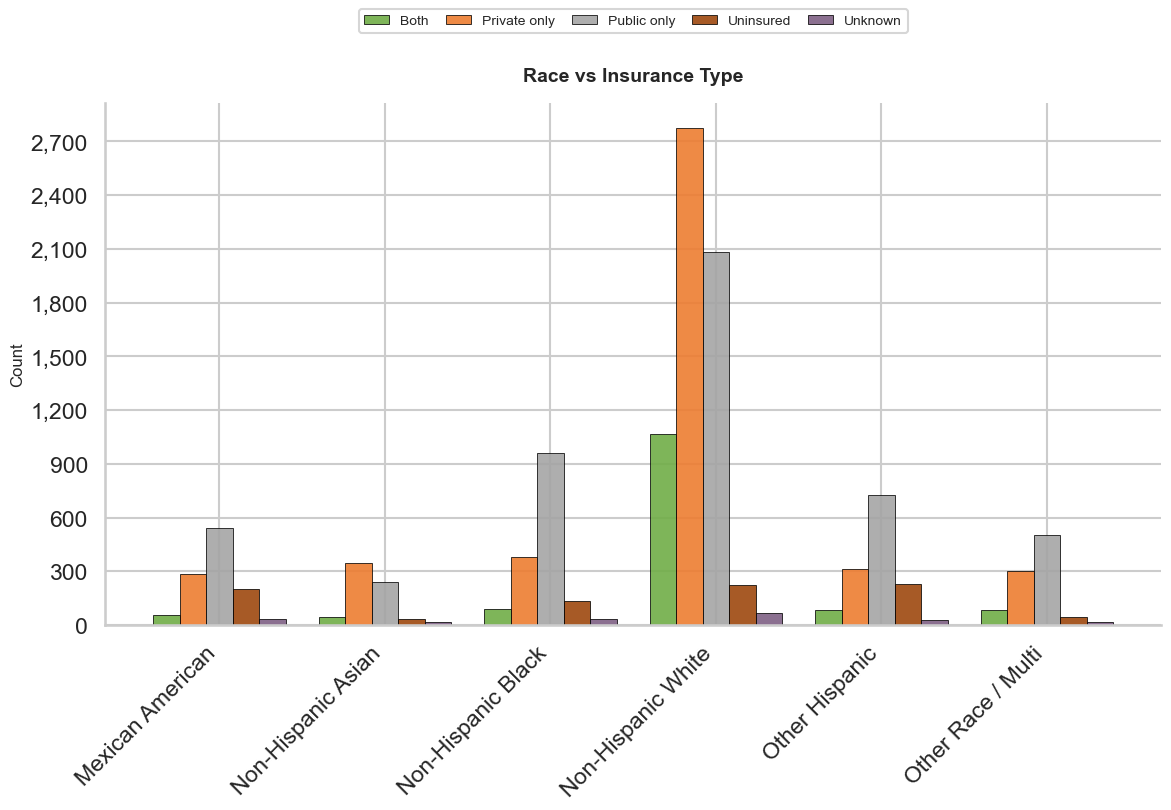

💡 KEY INSIGHTS: Race × Insurance Type
✓ Dominant insurance for Mexican American: Public only (49%)
✓ Dominant insurance for Non-Hispanic Asian: Private only (51%)
✓ Dominant insurance for Non-Hispanic Black: Public only (60%)
✓ Dominant insurance for Non-Hispanic White: Private only (45%)
✓ Dominant insurance for Other Hispanic: Public only (53%)
✓ Dominant insurance for Other Race / Multi: Public only (53%)


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 12, "legend.fontsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "savefig.dpi": 240
})

IMAGES_DIR = Path(globals().get("IMAGES_DIR", Path("reports") / "figures"))
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

def _wrap(text, width=18):
    s = str(text)
    if len(s) <= width: return s
    parts, line, out = s.split(), "", []
    for w in parts:
        if len(line) + 1 + len(w) <= width:
            line = (line + " " + w).strip()
        else:
            out.append(line); line = w
    if line: out.append(line)
    return "\n".join(out)

def _cycle_colors(k, offset=0):
    base = globals().get("PALETTE", None)
    if isinstance(base, (list, tuple)) and len(base) > 0:
        return [base[(offset+i) % len(base)] for i in range(k)]
    return list(sns.color_palette("Set2", n_colors=k))  

# 1) Education × IPR (Horizontal Boxplot) — fixed clipping
if 'education' in df.columns and 'income_poverty_ratio' in df.columns:
    subset = df[['education','income_poverty_ratio']].dropna().copy()
    if not subset.empty:
        med_order = (subset.groupby('education')['income_poverty_ratio']
                           .median().sort_values(ascending=True).index.tolist())
        pal = _cycle_colors(len(med_order), offset=0)

        fig, ax = plt.subplots(figsize=(12, 7))

        sns.boxplot(
            data=subset, y='education', x='income_poverty_ratio',
            order=med_order, showfliers=False, width=0.6, linewidth=1.2,
            color="white", ax=ax
        )

        for artist, c in zip(ax.artists, pal):
            artist.set_facecolor(c); artist.set_edgecolor(c); artist.set_alpha(0.9)
        lines_per_box = 6
        for i, c in enumerate(pal):
            for j in range(i*lines_per_box, min((i+1)*lines_per_box, len(ax.lines))):
                ax.lines[j].set_color(c); ax.lines[j].set_mfc(c); ax.lines[j].set_mec(c)

        ax.set_title("Income-Poverty Ratio by Education", pad=12)
        ax.set_xlabel("Income-Poverty Ratio")
        ax.set_ylabel("Education")

        xmax = float(subset['income_poverty_ratio'].max())
        ax.set_xlim(0, xmax * 1.05)

        fig.subplots_adjust(left=0.40, right=0.98, top=0.90, bottom=0.12)

        ax.margins(x=0.02)

        out_path = IMAGES_DIR / "income_by_education_box.png"
        fig.canvas.draw()
        fig.savefig(out_path, dpi=240, bbox_inches="tight", pad_inches=0.25)

        plt.show(); plt.close(fig)

        med = (subset.groupby('education')['income_poverty_ratio']
                      .median().sort_values(ascending=False))
        print("💡 KEY INSIGHTS: Education vs Income")
        print("="*60)
        for k, v in med.items():
            print(f"✓ Median IPR — {k}: {v:.2f}")
        print(f"✓ Gap (max - min): {med.iloc[0]-med.iloc[-1]:.2f}")
        print("="*60)

# 2) Race × Insurance (Grouped)
if 'race' in df.columns and 'insurance_type' in df.columns:
    cross = pd.crosstab(df['race'].fillna("Missing"),
                        df['insurance_type'].fillna("Missing"))
    cross = cross.loc[:, sorted(cross.columns.astype(str))]

    races = cross.index.tolist()
    types_ = cross.columns.tolist()
    ncat = len(types_)
    x = np.arange(len(races))
    w = 0.8 / max(ncat, 1)
    colors = _cycle_colors(ncat, offset=2)

    fig, ax = plt.subplots(figsize=(12, 9))

    for i, col in enumerate(types_):
        ax.bar(x + i*w, cross[col].values, width=w, label=str(col),
               color=colors[i], alpha=0.9, edgecolor="black", linewidth=0.6)

    ax.set_xticks(x + (ncat-1)*w/2)
    ax.set_xticklabels([_wrap(r, width=18) for r in races], rotation=45, ha='right')

    ax.set_ylabel("Count")
    ax.set_title("Race vs Insurance Type", pad=16) 
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(v):,}"))

    ncol = min(5, ncat)
    lg = ax.legend(
        frameon=True, ncol=ncol, loc="upper center",
        bbox_to_anchor=(0.5, 1.18),  
        borderaxespad=0.0, handlelength=1.8, columnspacing=1.2
    )

    fig.subplots_adjust(left=0.10, right=0.98, top=0.80, bottom=0.22)

    fig.canvas.draw()
    out_path = IMAGES_DIR / "race_vs_insurance_grouped.png"
    fig.savefig(out_path, dpi=240, bbox_inches="tight", pad_inches=0.18)
    plt.show(); plt.close(fig)

    print("💡 KEY INSIGHTS: Race × Insurance Type")
    print("="*60)
    share = cross.div(cross.sum(axis=1), axis=0).fillna(0)
    for r, dom in share.idxmax(axis=1).items():
        print(f"✓ Dominant insurance for {r}: {dom} ({share.loc[r, dom]:.0%})")
    print("="*60)

## 5) Health Indicators: A1C & SBP

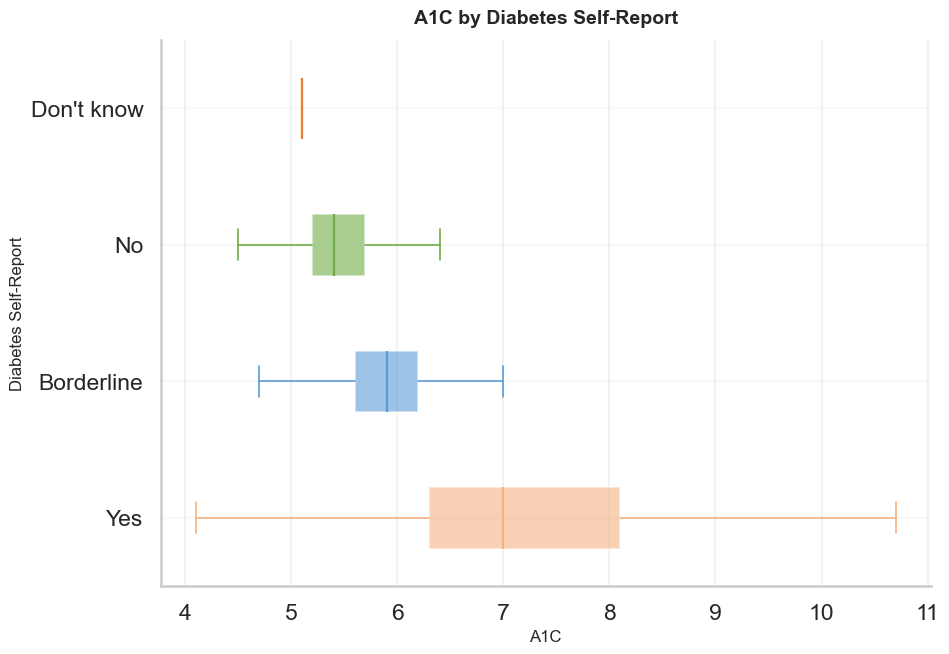

💡 KEY INSIGHTS: A1C & Self-Reported Diabetes
✓ Median A1C — Yes: 7.00
✓ Median A1C — Borderline: 5.90
✓ Median A1C — No: 5.40
✓ Median A1C — Don't know: 5.10
✓ Median gap across groups: 1.90


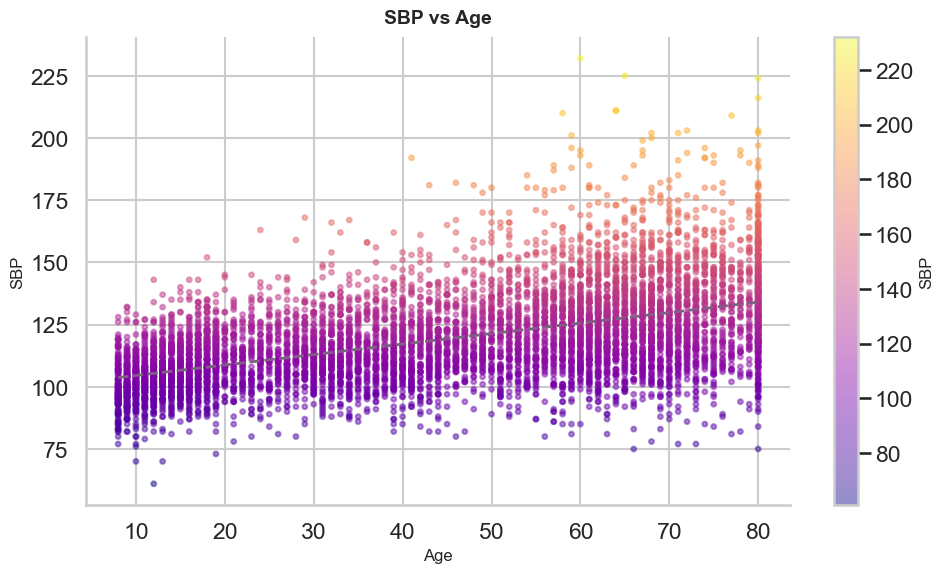

💡 KEY INSIGHTS: SBP vs Age
✓ Pearson correlation (age, sbp): 0.51
✓ Positive correlation suggests higher SBP among older participants.


In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter
import seaborn as sns

IMAGES_DIR = Path(globals().get("IMAGES_DIR", Path("reports") / "figures"))
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

def _cycle_colors(k, offset=0):
    base = globals().get("PALETTE", None)
    if isinstance(base, (list, tuple)) and len(base) > 0:
        return [base[(offset+i) % len(base)] for i in range(k)]
    return list(sns.color_palette("Set2", n_colors=k))

CMAP_SCATTER = globals().get("CMAP_SCATTER", "plasma")

if 'diabetes_self_report' in df.columns and 'a1c' in df.columns:
    subset = df[['diabetes_self_report', 'a1c']].dropna().copy()
    if not subset.empty:
        order = (
            subset.groupby('diabetes_self_report')['a1c']
                  .median()
                  .sort_values(ascending=False)
                  .index.tolist()
        )
        groups = [subset.loc[subset['diabetes_self_report'].eq(k), 'a1c'].values for k in order]
        colors = _cycle_colors(len(order), offset=0)

        fig, ax = plt.subplots(figsize=(11, 7))
        bp = ax.boxplot(
            groups,
            vert=False,                  
            showfliers=False,
            patch_artist=True,            
            tick_labels=[str(k) for k in order],
            boxprops=dict(linewidth=1.2),
            whiskerprops=dict(linewidth=1.0),
            capprops=dict(linewidth=1.0),
            medianprops=dict(linewidth=1.4)
        )

        for i, patch in enumerate(bp['boxes']):
            c = colors[i]
            patch.set(facecolor=c, edgecolor="white", alpha=0.6, linewidth=1.2)
            bp['whiskers'][2*i + 0].set(color=c, linewidth=1.2)
            bp['whiskers'][2*i + 1].set(color=c, linewidth=1.2)
            bp['caps'][2*i + 0].set(color=c, linewidth=1.2)
            bp['caps'][2*i + 1].set(color=c, linewidth=1.2)
            bp['medians'][i].set(color=c, linewidth=1.6)

        ax.set_xlabel("A1C")
        ax.set_ylabel("Diabetes Self-Report")
        ax.set_title("A1C by Diabetes Self-Report", pad=12, weight='bold')
        ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
        ax.grid(axis='x', alpha=0.25)
        ax.grid(axis='y', alpha=0.10)

        fig.subplots_adjust(left=0.28, right=0.98, top=0.90, bottom=0.12)

        out_path = IMAGES_DIR / "a1c_by_diabetes.png"
        fig.canvas.draw()
        fig.savefig(out_path, dpi=240, bbox_inches="tight", pad_inches=0.2)
        plt.show(); plt.close(fig)

        med = subset.groupby('diabetes_self_report')['a1c'].median().sort_values(ascending=False)
        print("💡 KEY INSIGHTS: A1C & Self-Reported Diabetes")
        print("="*60)
        for k, v in med.items():
            print(f"✓ Median A1C — {k}: {v:.2f}")
        print(f"✓ Median gap across groups: {med.iloc[0]-med.iloc[-1]:.2f}")
        print("="*60)


if 'sbp' in df.columns and 'age' in df.columns:
    sub = df[['age','sbp']].dropna().copy()
    if not sub.empty:
        fig, ax = plt.subplots(figsize=(10, 6))

        sc = ax.scatter(sub['age'], sub['sbp'],
                        s=12, alpha=0.45, c=sub['sbp'], cmap=CMAP_SCATTER)

        z = np.polyfit(sub['age'], sub['sbp'], 1)
        p = np.poly1d(z)
        xx = np.linspace(sub['age'].min(), sub['age'].max(), 200)
        ax.plot(xx, p(xx), linestyle="--", linewidth=2, color=_cycle_colors(7)[6])

        cbar = plt.colorbar(sc, ax=ax); cbar.set_label("SBP")
        ax.set_xlabel("Age")
        ax.set_ylabel("SBP")
        ax.set_title("SBP vs Age", pad=10)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

        fig.subplots_adjust(bottom=0.14, left=0.10, right=0.98, top=0.92)
        out_path = IMAGES_DIR / "sbp_vs_age.png"
        fig.canvas.draw()
        fig.savefig(out_path, dpi=240, bbox_inches="tight", pad_inches=0.15)
        plt.show(); plt.close(fig)

        r = np.corrcoef(sub['age'], sub['sbp'])[0, 1]
        print("💡 KEY INSIGHTS: SBP vs Age")
        print("="*60)
        print(f"✓ Pearson correlation (age, sbp): {r:.2f}")
        print("✓ Positive correlation suggests higher SBP among older participants."
              if r > 0 else "✓ Non-positive correlation.")
        print("="*60)


## 6) Lifestyle: Smoking, Activity & Sleep

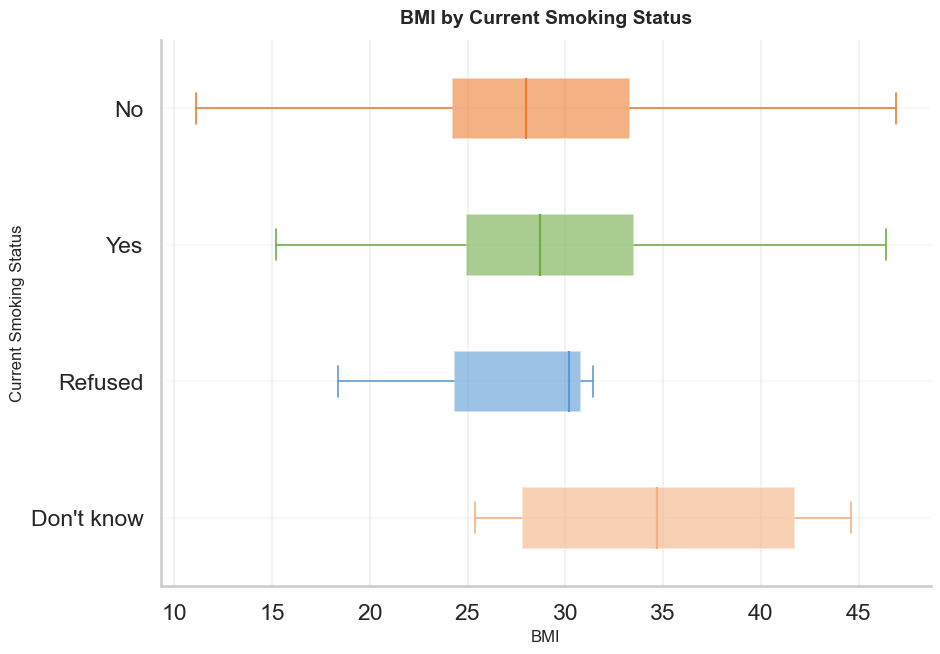

💡 KEY INSIGHTS: Smoking & BMI
✓ Mean BMI — Don't know: 34.85
✓ Mean BMI — Yes: 29.81
✓ Mean BMI — No: 29.56
✓ Mean BMI — Refused: 26.67
✓ Highest vs lowest mean BMI: Don't know vs Refused (gap 8.18)


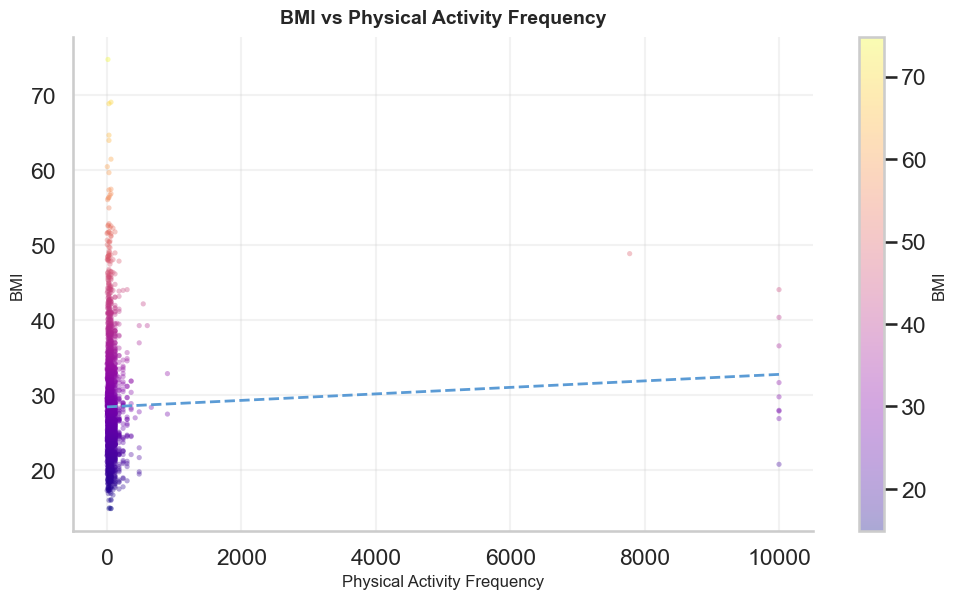

💡 KEY INSIGHTS: Physical Activity & BMI
✓ Pearson correlation (activity, BMI): 0.04
✓ Weak/positive relationship observed.


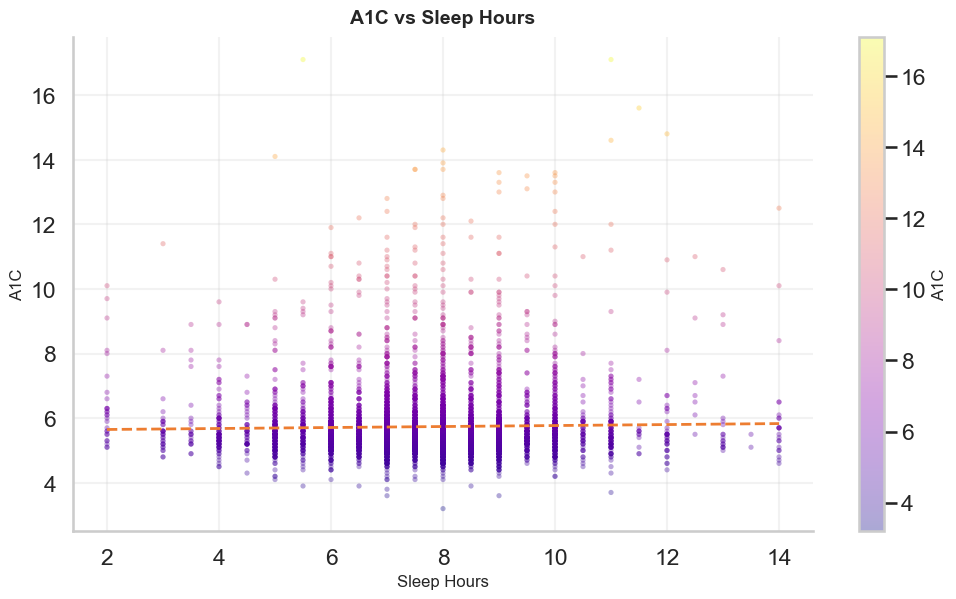

💡 KEY INSIGHTS: Sleep & A1C
✓ Pearson correlation (sleep, A1C): 0.02


In [7]:
if 'smoking_current' in df.columns and 'bmi' in df.columns:
    subset = df[['smoking_current', 'bmi']].dropna().copy()
    if not subset.empty:
        order = (
            subset.groupby('smoking_current')['bmi']
                  .median()
                  .sort_values(ascending=False)
                  .index.tolist()
        )
        groups = [subset.loc[subset['smoking_current'].eq(k), 'bmi'].values for k in order]
        colors = _cycle_colors(len(order), offset=0)

        fig, ax = plt.subplots(figsize=(11, 7))
        bp = ax.boxplot(
            groups,
            vert=False,                    
            showfliers=False,
            patch_artist=True,               
            tick_labels=[str(k) for k in order],
            boxprops=dict(linewidth=1.2),
            whiskerprops=dict(linewidth=1.0),
            capprops=dict(linewidth=1.0),
            medianprops=dict(linewidth=1.6)
        )

        for i, patch in enumerate(bp['boxes']):
            c = colors[i]
            patch.set(facecolor=c, edgecolor="white", alpha=0.6, linewidth=1.2)
            bp['whiskers'][2*i + 0].set(color=c, linewidth=1.2)
            bp['whiskers'][2*i + 1].set(color=c, linewidth=1.2)
            bp['caps'][2*i + 0].set(color=c, linewidth=1.2)
            bp['caps'][2*i + 1].set(color=c, linewidth=1.2)
            bp['medians'][i].set(color=c, linewidth=1.6)

        ax.set_xlabel("BMI")
        ax.set_ylabel("Current Smoking Status")
        ax.set_title("BMI by Current Smoking Status", pad=12, weight='bold')
        ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
        ax.grid(axis='x', alpha=0.25)
        ax.grid(axis='y', alpha=0.10)

        fig.subplots_adjust(left=0.28, right=0.98, top=0.90, bottom=0.12)
        out_path = IMAGES_DIR / "bmi_by_smoking.png"
        fig.canvas.draw()
        fig.savefig(out_path, dpi=240, bbox_inches="tight", pad_inches=0.2)
        plt.show(); plt.close(fig)

        mean_bmi = subset.groupby('smoking_current')['bmi'].mean().sort_values(ascending=False)
        print("💡 KEY INSIGHTS: Smoking & BMI")
        print("="*60)
        for k, v in mean_bmi.items():
            print(f"✓ Mean BMI — {k}: {v:.2f}")
        top, bottom = mean_bmi.index[0], mean_bmi.index[-1]
        print(f"✓ Highest vs lowest mean BMI: {top} vs {bottom} (gap {mean_bmi.iloc[0]-mean_bmi.iloc[-1]:.2f})")
        print("="*60)

if 'physical_activity_freq' in df.columns and 'bmi' in df.columns:
    pa = df[['physical_activity_freq', 'bmi']].dropna()
    if not pa.empty:
        fig, ax = plt.subplots(figsize=(10.5, 6.5))
        # 兜底散点配色
        _cmap = globals().get("CMAP_SCATTER", "viridis")
        sc = ax.scatter(
            pa['physical_activity_freq'], pa['bmi'],
            s=14, alpha=0.35, c=pa['bmi'], cmap=_cmap, edgecolors="none"
        )
        # 线性趋势
        z = np.polyfit(pa['physical_activity_freq'], pa['bmi'], 1)
        p = np.poly1d(z)
        xx = np.linspace(pa['physical_activity_freq'].min(), pa['physical_activity_freq'].max(), 200)
        ax.plot(xx, p(xx), linestyle="--", linewidth=2, color=_cycle_colors(1, offset=1)[0])

        cbar = plt.colorbar(sc, ax=ax); cbar.set_label("BMI")
        ax.set_xlabel("Physical Activity Frequency")
        ax.set_ylabel("BMI")
        ax.set_title("BMI vs Physical Activity Frequency", pad=10, weight='bold')
        ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
        ax.grid(alpha=0.25)

        fig.subplots_adjust(bottom=0.14, left=0.10, right=0.98, top=0.90)
        out_path = IMAGES_DIR / "bmi_vs_activity.png"
        fig.canvas.draw()
        fig.savefig(out_path, dpi=240, bbox_inches="tight", pad_inches=0.15)
        plt.show(); plt.close(fig)

        r = np.corrcoef(pa['physical_activity_freq'], pa['bmi'])[0, 1]
        print("💡 KEY INSIGHTS: Physical Activity & BMI")
        print("="*60)
        print(f"✓ Pearson correlation (activity, BMI): {r:.2f}")
        print("✓ Higher activity tends to relate with lower BMI." if r < 0 else "✓ Weak/positive relationship observed.")
        print("="*60)

if 'sleep_hours' in df.columns and 'a1c' in df.columns:
    sl = df[['sleep_hours', 'a1c']].dropna()
    if not sl.empty:
        fig, ax = plt.subplots(figsize=(10.5, 6.5))
        _cmap = globals().get("CMAP_SCATTER", "viridis")
        sc = ax.scatter(
            sl['sleep_hours'], sl['a1c'],
            s=14, alpha=0.35, c=sl['a1c'], cmap=_cmap, edgecolors="none"
        )
        z = np.polyfit(sl['sleep_hours'], sl['a1c'], 1)
        p = np.poly1d(z)
        xx = np.linspace(sl['sleep_hours'].min(), sl['sleep_hours'].max(), 200)
        ax.plot(xx, p(xx), linestyle="--", linewidth=2, color=_cycle_colors(1, offset=3)[0])

        cbar = plt.colorbar(sc, ax=ax); cbar.set_label("A1C")
        ax.set_xlabel("Sleep Hours")
        ax.set_ylabel("A1C")
        ax.set_title("A1C vs Sleep Hours", pad=10, weight='bold')
        ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
        ax.grid(alpha=0.25)

        fig.subplots_adjust(bottom=0.14, left=0.10, right=0.98, top=0.90)
        out_path = IMAGES_DIR / "a1c_vs_sleep.png"
        fig.canvas.draw()
        fig.savefig(out_path, dpi=240, bbox_inches="tight", pad_inches=0.15)
        plt.show(); plt.close(fig)

        r = np.corrcoef(sl['sleep_hours'], sl['a1c'])[0, 1]
        print("💡 KEY INSIGHTS: Sleep & A1C")
        print("="*60)
        print(f"✓ Pearson correlation (sleep, A1C): {r:.2f}")
        print("="*60)


## 7) Correlations

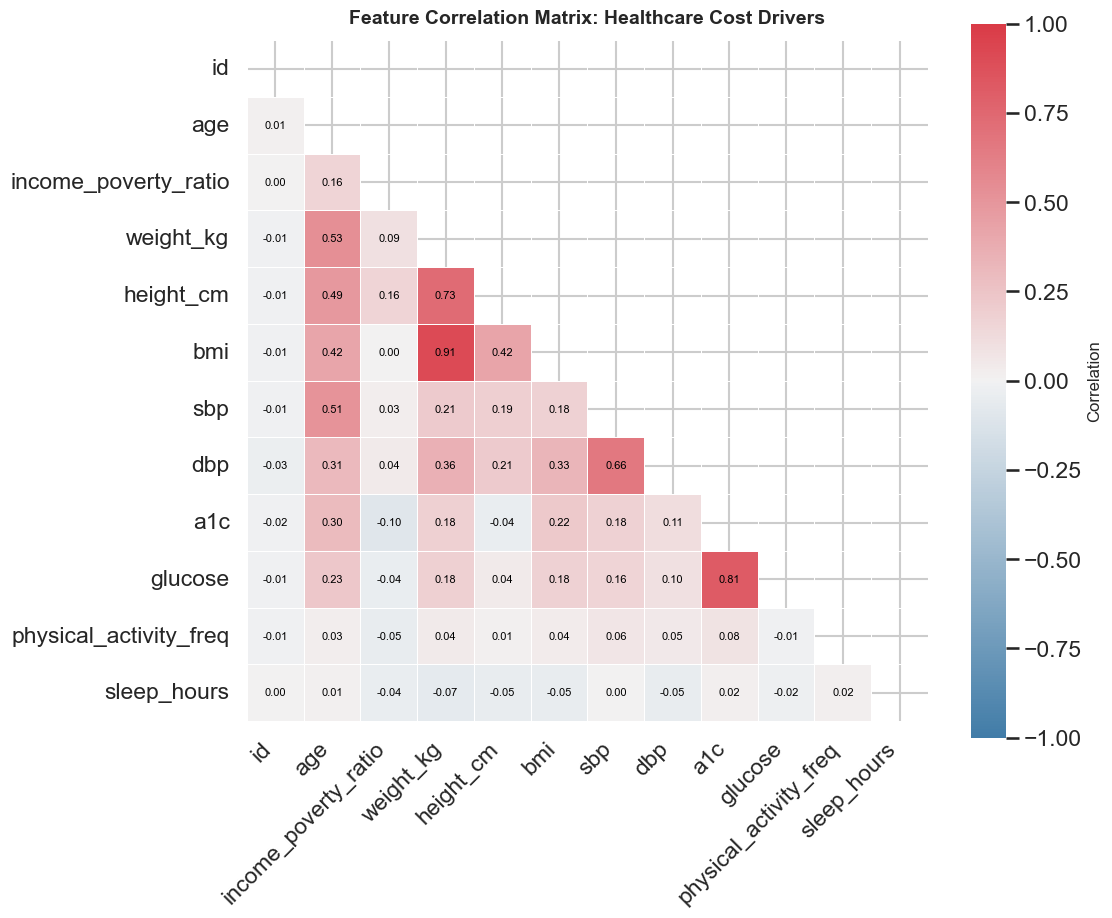

💡 KEY INSIGHTS: Top Numeric Correlations (by |r|)
✓ bmi ↔ weight_kg: 0.91 (|r|=0.91)
✓ glucose ↔ a1c: 0.81 (|r|=0.81)
✓ height_cm ↔ weight_kg: 0.73 (|r|=0.73)
✓ dbp ↔ sbp: 0.66 (|r|=0.66)
✓ weight_kg ↔ age: 0.53 (|r|=0.53)
✓ sbp ↔ age: 0.51 (|r|=0.51)
✓ height_cm ↔ age: 0.49 (|r|=0.49)
✓ bmi ↔ height_cm: 0.42 (|r|=0.42)
✓ bmi ↔ age: 0.42 (|r|=0.42)
✓ dbp ↔ weight_kg: 0.36 (|r|=0.36)


In [8]:
num_df = df.select_dtypes(include=[np.number]).copy()
if not num_df.empty:
    corr = num_df.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    n = corr.shape[0]
    fig_w = min(0.6 * n + 4, 20)
    fig_h = min(0.6 * n + 3, 18)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    cmap = sns.diverging_palette(240, 10, as_cmap=True)  
    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        vmin=-1, vmax=1, center=0,
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Correlation"},
        annot=True, fmt=".2f",
        annot_kws={"size": 8, "color": "black"},
        xticklabels=corr.columns,
        yticklabels=corr.columns,
        ax=ax
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_title("Feature Correlation Matrix: Healthcare Cost Drivers", pad=12, weight="bold")

    fig.subplots_adjust(left=0.22, bottom=0.22, right=0.98, top=0.92)
    out_path = IMAGES_DIR / "correlation_heatmap.png"
    fig.canvas.draw()
    fig.savefig(out_path, dpi=240, bbox_inches="tight", pad_inches=0.25)
    plt.show(); plt.close(fig)

    abs_corr = corr.abs().copy()
    np.fill_diagonal(abs_corr.values, np.nan)
    tril_idx = np.tril_indices_from(abs_corr, k=-1)
    tril_series = pd.Series(
        abs_corr.values[tril_idx],
        index=pd.MultiIndex.from_arrays(
            [abs_corr.index.values[tril_idx[0]], abs_corr.columns.values[tril_idx[1]]]
        )
    ).dropna().sort_values(ascending=False)

    top_pairs = tril_series.head(10)

    print("💡 KEY INSIGHTS: Top Numeric Correlations (by |r|)")
    print("="*60)
    for (r1, r2), val in top_pairs.items():
        sign = corr.loc[r1, r2]
        print(f"✓ {r1} ↔ {r2}: {sign:.2f} (|r|={val:.2f})")
    print("="*60)
